# Analysis of Algorithms - Python Examples with Math and Visualization
This notebook illustrates formulas from Chapter 2 using Python code, math notation, symbol explanations, and visual comparisons.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random

## 1. Newton-Raphson Method
Formula:

```math
x_{t+1} = x_t - \frac{f'(x_t)}{f''(x_t)}
```

**Symbols:**
- $x_t$: current value
- $f'(x_t)$: first derivative of function $f$
- $f''(x_t)$: second derivative of $f$

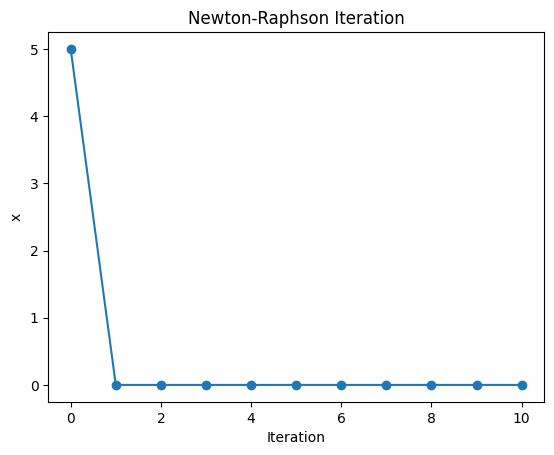

In [18]:
def newton_raphson(f, df, d2f, x0, max_iter=10):
    x = x0
    history = [x]
    for t in range(max_iter):
        x = x - df(x)/d2f(x)
        history.append(x)
    return history

f  = lambda x: x**2 - 2
df = lambda x: 2*x
d2f= lambda x: 2

history = newton_raphson(f, df, d2f, x0=5.0, max_iter=10)

plt.plot(history, marker="o")
plt.title("Newton-Raphson Iteration")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()

## 2. General Iterative Algorithm
Formula:
```math
x_{t+1} = A(x_t, p, \varepsilon)
```
**Symbols:**
- $x_t$: current solution
- $p$: parameter controlling update
- $\varepsilon$: random noise

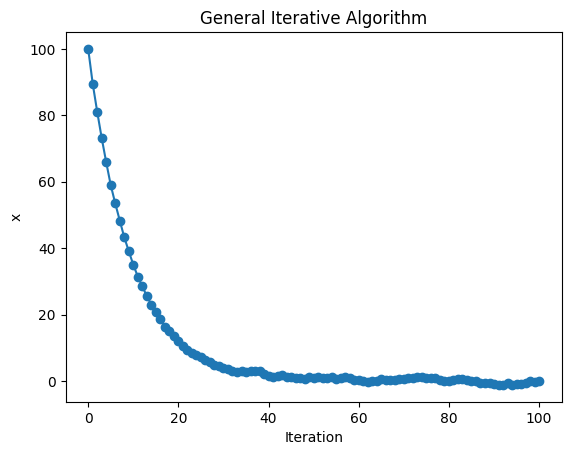

In [ ]:
def simple_algorithm(x, p, eps):
    return x - p * x + eps

x = 10
history = [x]
for t in range(10):
    eps = random.uniform(-0.5, 0.5)
    x = simple_algorithm(x, p=0.1, eps=eps)
    history.append(x)

plt.plot(history, marker="o")
plt.title("General Iterative Algorithm")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()

## 3. Population-Based Iteration
Formula:
```math
X_{t+1} = A(X_t, p, \varepsilon)
```
**Symbols:**
- $X_t$: vector of candidate solutions
- $p$: algorithm parameters
- $\varepsilon$: random noise per solution

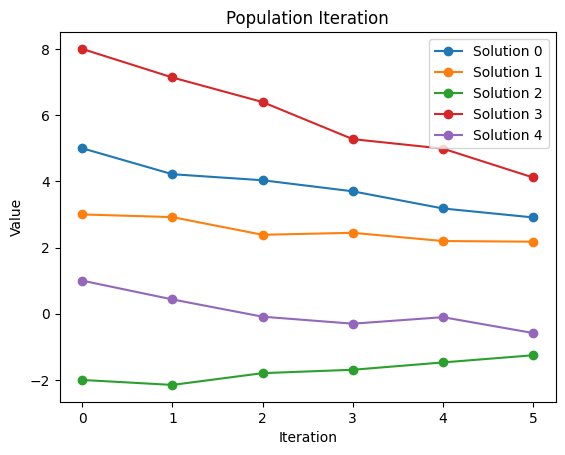

In [4]:
def population_update(X, p, eps):
    return X - p * X + eps

X = np.array([5, 3, -2, 8, 1], dtype=float)
history = [X.copy()]

for t in range(5):
    eps = np.random.uniform(-0.5, 0.5, size=len(X))
    X = population_update(X, p=0.1, eps=eps)
    history.append(X.copy())

history = np.array(history)
for i in range(history.shape[1]):
    plt.plot(history[:, i], marker="o", label=f"Solution {i}")
plt.title("Population Iteration")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.legend()
plt.show()

## 4. Self-Organization View (Gradient Descent Analogy)
Formula:
```math
f(x_t) \to f_{min}(x^*)
```
**Symbols:**
- $f(x)$: objective function
- $x^*$: optimal solution

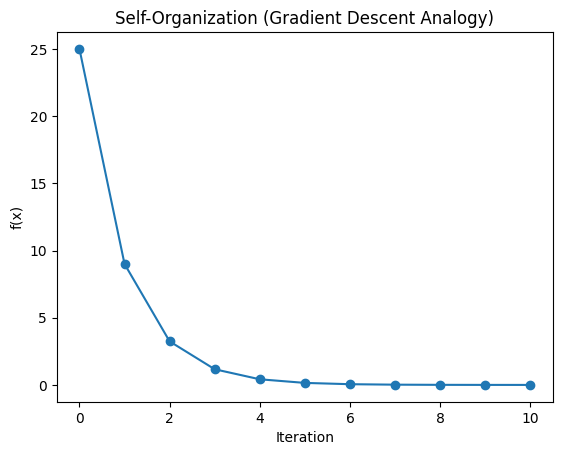

In [5]:
def objective(x):
    return x**2

x = 5
history = [objective(x)]
for t in range(10):
    x = x - 0.2 * (2*x)
    history.append(objective(x))

plt.plot(history, marker="o")
plt.title("Self-Organization (Gradient Descent Analogy)")
plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.show()

## 5. Mutation Operator
Formula:
```math
x = x + (x_{newmove} - x)
```
**Symbols:**
- $x$: current solution
- $x_{newmove}$: randomly generated new move

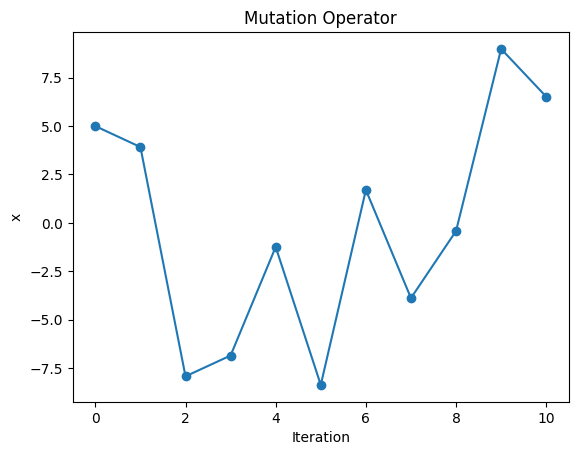

In [6]:
x = 5
history = [x]
for t in range(10):
    new_move = random.uniform(-10, 10)
    x = x + (new_move - x)
    history.append(x)

plt.plot(history, marker="o")
plt.title("Mutation Operator")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()

## 6. Particle Swarm Optimization
Formula:
```math
v_{i}^{t+1} = v_i^t + \alpha \varepsilon_1 (g^* - x_i^t) + \beta \varepsilon_2 (x_i^* - x_i^t)
```
**Symbols:**
- $x_i$: position of particle
- $v_i$: velocity
- $g^*$: global best
- $x_i^*$: personal best
- $\alpha, \beta$: learning parameters
- $\varepsilon_1, \varepsilon_2$: random numbers

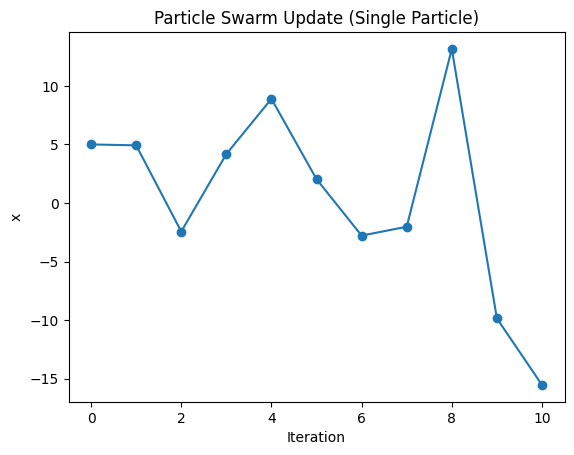

In [7]:
alpha, beta = 2, 2
g_best = 0.0
x, v = 5.0, 0.0
p_best = x

history = [x]
for t in range(10):
    eps1, eps2 = np.random.rand(), np.random.rand()
    v = v + alpha*eps1*(g_best - x) + beta*eps2*(p_best - x)
    x = x + v
    history.append(x)

plt.plot(history, marker="o")
plt.title("Particle Swarm Update (Single Particle)")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()

## 7. Firefly Algorithm
Formula:
```math
x_i^{t+1} = x_i^t + \beta_0 e^{-\gamma r_{ij}^2}(x_j^t - x_i^t) + \alpha \varepsilon
```
**Symbols:**
- $x_i$: position of firefly $i$
- $x_j$: position of firefly $j$
- $r_{ij}$: distance between fireflies
- $\beta_0$: attractiveness
- $\gamma$: absorption coefficient
- $\alpha$: randomization parameter
- $\varepsilon$: random number

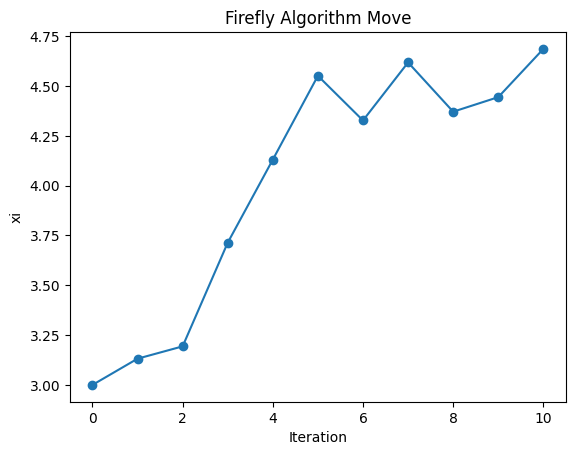

In [8]:
def firefly_move(xi, xj, beta0=1, gamma=1, alpha=0.2):
    rij = abs(xi - xj)
    attraction = beta0 * np.exp(-gamma * rij**2) * (xj - xi)
    random_step = alpha * np.random.randn()
    return xi + attraction + random_step

xi, xj = 3.0, -1.0
history = [xi]
for t in range(10):
    xi = firefly_move(xi, xj)
    history.append(xi)

plt.plot(history, marker="o")
plt.title("Firefly Algorithm Move")
plt.xlabel("Iteration")
plt.ylabel("xi")
plt.show()

## 8. Cuckoo Search with Lévy Flight
Formula:
```math
x^{t+1}_i = x^t_i + \alpha L(s, \lambda)
```
**Symbols:**
- $x_i$: current solution
- $\alpha$: step size
- $L(s,\lambda)$: Lévy flight distribution

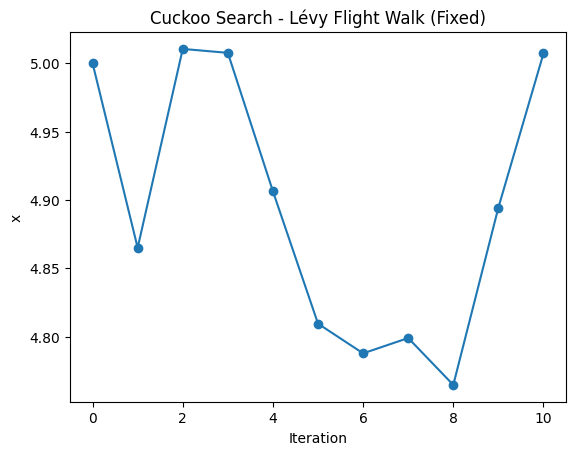

In [9]:
def levy_flight(Lambda=1.5):
    # Using the Mantegna algorithm
    sigma = (math.gamma(1+Lambda) * math.sin(math.pi*Lambda/2) /
            (math.gamma((1+Lambda)/2)*Lambda*2**((Lambda-1)/2)))**(1/Lambda)
    u = np.random.randn() * sigma
    v = np.random.randn()
    return u / abs(v)**(1/Lambda)

# Test run
x = 5.0
history = [x]
for t in range(10):
    step = levy_flight()
    x = x + 0.1 * step
    history.append(x)

import matplotlib.pyplot as plt
plt.plot(history, marker="o")
plt.title("Cuckoo Search - Lévy Flight Walk (Fixed)")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()

## 9. Bat Algorithm
Formula:
```math
v_i^t = v_i^{t-1} + (x_i^{t-1} - x^*) f_i
```
**Symbols:**
- $x_i$: bat position
- $v_i$: bat velocity
- $x^*$: best solution found so far
- $f_i$: frequency

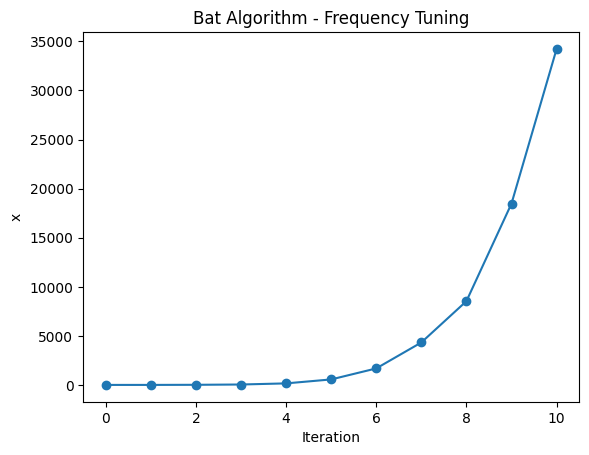

In [10]:
fmin, fmax = 0, 2
x, v = 5.0, 0.0
x_best = 0.0

history = [x]
for t in range(10):
    beta = np.random.rand()
    f = fmin + (fmax - fmin) * beta
    v = v + (x - x_best) * f
    x = x + v
    history.append(x)

plt.plot(history, marker="o")
plt.title("Bat Algorithm - Frequency Tuning")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()

## 10. Flower Pollination Algorithm
Formula:
```math
x^{t+1}_i = x^t_i + \gamma L(\lambda)(g^* - x^t_i)
```
**Symbols:**
- $x_i$: candidate solution
- $g^*$: global best
- $\gamma$: scaling factor
- $L(\lambda)$: Lévy flight step

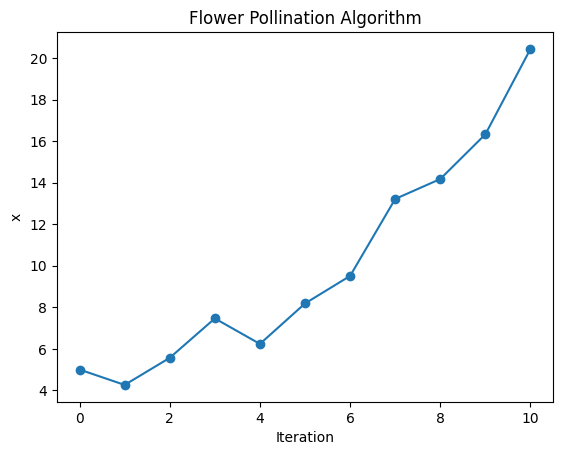

In [11]:
def global_pollination(x, g_best, gamma=0.1):
    return x + gamma * levy_flight() * (g_best - x)

def local_pollination(x, xj, xk, eps=None):
    if eps is None: eps = np.random.rand()
    return x + eps * (xj - xk)

x, g_best = 5.0, 0.0
xj, xk = 2.0, -3.0

history = [x]
for t in range(10):
    if np.random.rand() < 0.5:
        x = global_pollination(x, g_best)
    else:
        x = local_pollination(x, xj, xk)
    history.append(x)

plt.plot(history, marker="o")
plt.title("Flower Pollination Algorithm")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()

## 11. Visual Comparison: Optimization vs No Optimization
Here we compare how optimization methods (gradient descent) find minima compared to random search (no optimization).

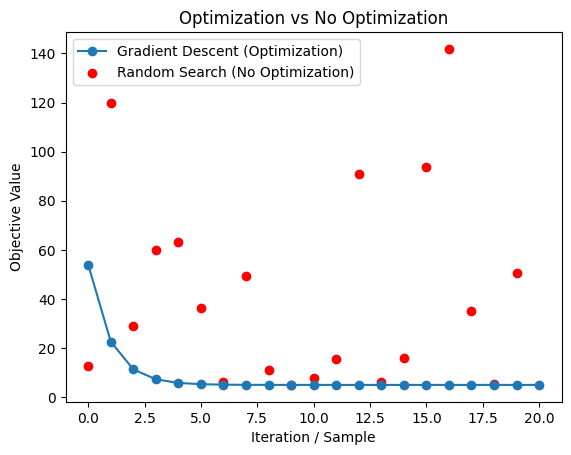

In [12]:
def objective(x): return (x-3)**2 + 5

# Random search (no optimization)
random_vals = [random.uniform(-10, 10) for _ in range(20)]
random_scores = [objective(v) for v in random_vals]

# Gradient descent (optimization)
x = 10
gd_history = [objective(x)]
for t in range(20):
    x = x - 0.2*(2*(x-3))
    gd_history.append(objective(x))

plt.plot(gd_history, label="Gradient Descent (Optimization)", marker="o")
plt.scatter(range(len(random_scores)), random_scores, color="red", label="Random Search (No Optimization)")
plt.title("Optimization vs No Optimization")
plt.xlabel("Iteration / Sample")
plt.ylabel("Objective Value")
plt.legend()
plt.show()